In [1]:
 # import pandas library
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,confusion_matrix
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
 # Reading csv file
df = pd.read_csv("dataset_Heart.csv")
df.head()

,age,sexe,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,64,1,0,128,263,0,1,105,1,0.2,1,1,3,1
1,46,0,2,142,177,0,0,160,1,1.4,0,0,2,1
2,65,0,2,140,417,1,0,157,0,0.8,2,1,2,1
3,66,1,0,160,228,0,0,138,0,2.3,2,0,1,1
4,57,1,0,165,289,1,0,124,0,1.0,1,3,3,0


In [3]:
 df = df.drop_duplicates()

In [4]:
# Count ,min,max ,etc of each column
df.describe()

,age,sexe,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000,212.000000
mean,54.731132,0.679245,1.000000,132.033019,244.976415,0.160377,0.514151,149.561321,0.330189,1.088208,1.372642,0.759434,2.372642,0.542453
std,9.159377,0.467871,1.066509,17.370887,53.194665,0.367824,0.519558,21.971567,0.471394,1.134259,0.614059,1.032025,0.574173,0.499374
min,29.000000,0.000000,0.000000,94.000000,131.000000,0.000000,0.000000,88.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,209.000000,0.000000,0.000000,132.750000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,237.500000,0.000000,1.000000,152.000000,0.000000,0.850000,1.000000,0.000000,2.000000,1.000000
75%,62.000000,1.000000,2.000000,140.000000,271.750000,0.000000,1.000000,165.000000,1.000000,1.650000,2.000000,1.000000,3.000000,1.000000
max,76.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,5.600000,2.000000,4.000000,3.000000,1.000000


In [5]:
# Information about each column data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       212 non-null    int64  
 1   sexe      212 non-null    int64  
 2   cp        212 non-null    int64  
 3   trestbps  212 non-null    int64  
 4   chol      212 non-null    int64  
 5   fbs       212 non-null    int64  
 6   restecg   212 non-null    int64  
 7   thalach   212 non-null    int64  
 8   exang     212 non-null    int64  
 9   oldpeak   212 non-null    float64
 10  slope     212 non-null    int64  
 11  ca        212 non-null    int64  
 12  thal      212 non-null    int64  
 13  target    212 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 23.3 KB


In [6]:
#Finding null values in each column
df.isna().sum()# Information about each column data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       212 non-null    int64  
 1   sexe      212 non-null    int64  
 2   cp        212 non-null    int64  
 3   trestbps  212 non-null    int64  
 4   chol      212 non-null    int64  
 5   fbs       212 non-null    int64  
 6   restecg   212 non-null    int64  
 7   thalach   212 non-null    int64  
 8   exang     212 non-null    int64  
 9   oldpeak   212 non-null    float64
 10  slope     212 non-null    int64  
 11  ca        212 non-null    int64  
 12  thal      212 non-null    int64  
 13  target    212 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 23.3 KB


In [7]:
df.head()

,age,sexe,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,64,1,0,128,263,0,1,105,1,0.2,1,1,3,1
1,46,0,2,142,177,0,0,160,1,1.4,0,0,2,1
2,65,0,2,140,417,1,0,157,0,0.8,2,1,2,1
3,66,1,0,160,228,0,0,138,0,2.3,2,0,1,1
4,57,1,0,165,289,1,0,124,0,1.0,1,3,3,0


In [8]:
df.fbs.unique()

array([0, 1])

In [9]:
subSet1 = df[['age','cp','chol','thalach']]

In [10]:
subSet2 = df[['exang','slope','target']]

In [11]:
merged_df = subSet1.merge(right=subSet2,how='cross')
merged_df.head()

,age,cp,chol,thalach,exang,slope,target
0,64,0,263,105,1,1,1
1,64,0,263,105,1,0,1
2,64,0,263,105,0,2,1
3,64,0,263,105,0,2,1
4,64,0,263,105,0,1,0


In [12]:
df.columns

Index(['age', 'sexe', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [13]:
def remove_outliers(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    threshold = 1.5 * IQR
    outlier_mask = (column < Q1 - threshold) | (column > Q3 + threshold)
    return column[~outlier_mask]

In [14]:
# Remove outliers for each column using a loop
col_name = ['cp','thalach','exang','oldpeak','slope','ca']
for col in col_name:
    df[col] = remove_outliers(df[col])

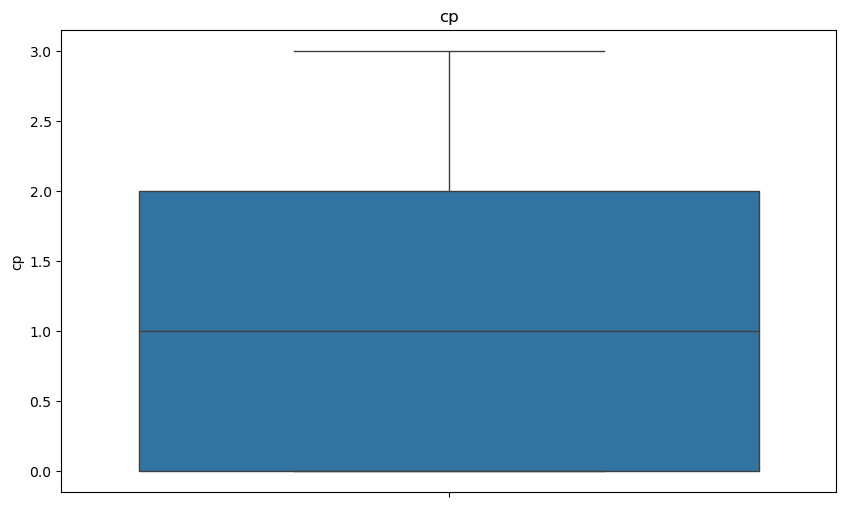

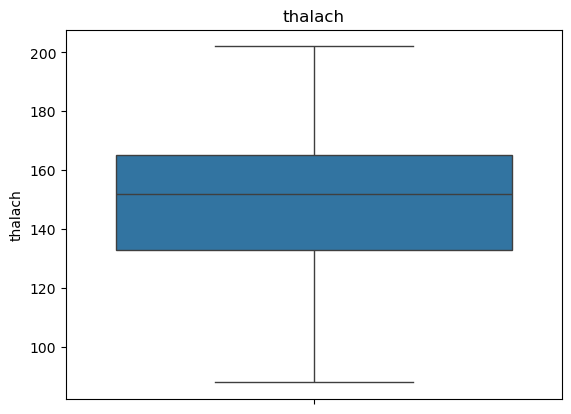

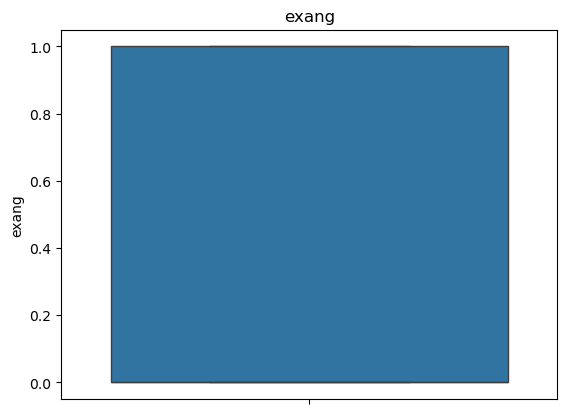

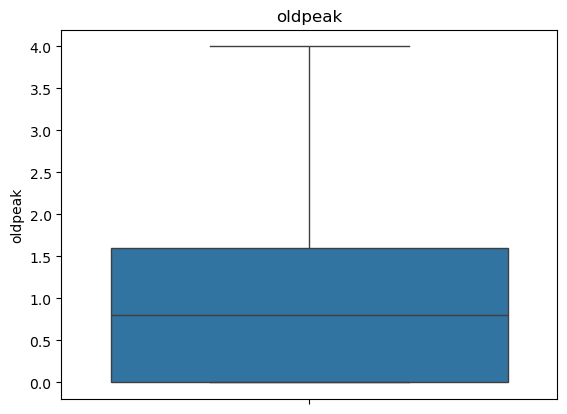

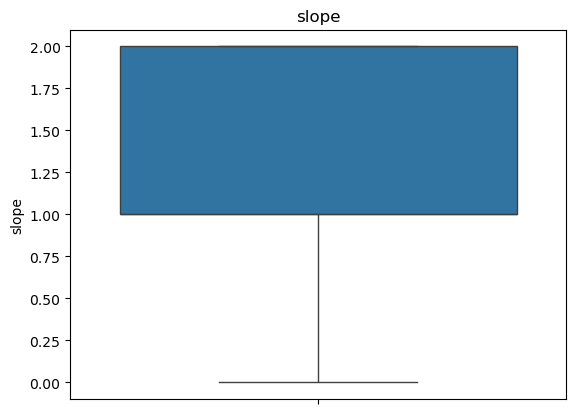

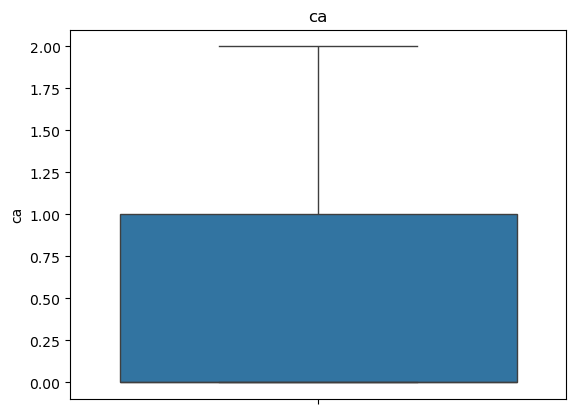

In [15]:
plt.figure(figsize=(10, 6))  # Adjust the figure size if needed
for col in col_name:
    sns.boxplot(data=df[col])
    plt.title(col)
    plt.show()

In [16]:
df = df.dropna()

In [17]:
df.isna().sum()

age         0
sexe        0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [18]:
df = df.drop('fbs',axis=1)

Correlation with the Target:
age        -0.141383
sexe       -0.342506
cp          0.432323
trestbps   -0.155796
chol       -0.074646
restecg     0.116095
thalach     0.328455
exang      -0.445435
oldpeak    -0.448892
slope       0.306024
ca         -0.441641
thal       -0.468544
Name: target, dtype: float64



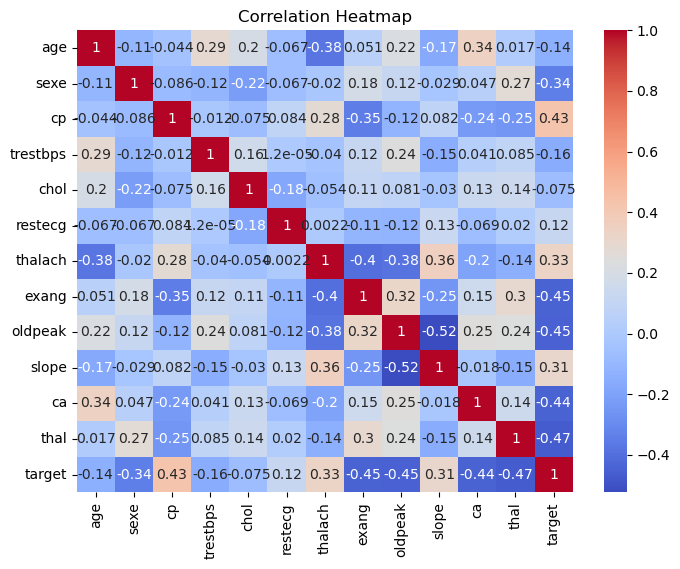

In [19]:
# Compute correlations between features and target
correlations = df.corr()['target'].drop('target')

# Print correlations
print("Correlation with the Target:")
print(correlations)
print()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [20]:
# df.isna().sum()

In [22]:
# splitting data using train test split
x = df[['cp','thalach','exang','oldpeak','slope','ca']]
y = df.target
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

x_train.shape,x_test.shape,y_train.shape,y_test.shape

((153, 6), (39, 6), (153,), (39,))

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()

In [25]:
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [26]:
y_train= np.array(y_train).reshape(-1, 1)
y_test= np.array(y_test).reshape(-1, 1)

In [27]:
y_train.shape

(153, 1)

In [28]:
model = LogisticRegression()
model.fit(x_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(x_test_scaled)

# Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8974358974358975


C:\Users\Rohit\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [29]:
#Classification model using Decision Tree
from sklearn.tree import DecisionTreeClassifier
tc=DecisionTreeClassifier(criterion='entropy')
tc.fit(x_train_scaled,y_train)
y_pred=tc.predict(x_test_scaled)

print("Training Accuracy Score :",accuracy_score(y_pred,y_test))
print("Training Confusion Matrix  :",confusion_matrix(y_pred,y_test))

Training Accuracy Score : 0.717948717948718
Training Confusion Matrix  : [[12  7]
 [ 4 16]]
